# **Amazon E-Commerce Sales Data Analysis**

This project analyzes Amazon sales data to understand customer purchasing behavior,
revenue trends, product performance, and geographical sales distribution.

Tools Used:
- Python
- Pandas
- Matplotlib
- Seaborn
- Google Colab

Objectives:
- Clean and prepare raw sales data
- Perform exploratory data analysis
- Visualize sales trends
- Generate business insights

Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

Upload Dataset

In [1]:
from google.colab import files
uploaded = files.upload()

Saving Amazon.csv to Amazon.csv


In [3]:
df = pd.read_csv("Amazon.csv")

df.head()

,OrderID,OrderDate,CustomerID,CustomerName,ProductID,ProductName,Category,Brand,Quantity,UnitPrice,Discount,Tax,ShippingCost,TotalAmount,PaymentMethod,OrderStatus,City,State,Country,SellerID
0,ORD0000001,2023-01-31,CUST001504,Vihaan Sharma,P00014,Drone Mini,Books,BrightLux,3,106.59,0.00,0.00,0.09,319.86,Debit Card,Delivered,Washington,DC,India,SELL01967
1,ORD0000002,2023-12-30,CUST000178,Pooja Kumar,P00040,Microphone,Home & Kitchen,UrbanStyle,1,251.37,0.05,19.10,1.74,259.64,Amazon Pay,Delivered,Fort Worth,TX,United States,SELL01298
2,ORD0000003,2022-05-10,CUST047516,Sneha Singh,P00044,Power Bank 20000mAh,Clothing,UrbanStyle,3,35.03,0.10,7.57,5.91,108.06,Debit Card,Delivered,Austin,TX,United States,SELL00908
3,ORD0000004,2023-07-18,CUST030059,Vihaan Reddy,P00041,Webcam Full HD,Home & Kitchen,Zenith,5,33.58,0.15,11.42,5.53,159.66,Cash on Delivery,Delivered,Charlotte,NC,India,SELL01164
4,ORD0000005,2023-02-04,CUST048677,Aditya Kapoor,P00029,T-Shirt,Clothing,KiddoFun,2,515.64,0.25,38.67,9.23,821.36,Credit Card,Cancelled,San Antonio,TX,Canada,SELL01411


understand the dataset

In [4]:
df.shape

(100000, 20)

In [5]:
df.columns

Index(['OrderID', 'OrderDate', 'CustomerID', 'CustomerName', 'ProductID',
       'ProductName', 'Category', 'Brand', 'Quantity', 'UnitPrice', 'Discount',
       'Tax', 'ShippingCost', 'TotalAmount', 'PaymentMethod', 'OrderStatus',
       'City', 'State', 'Country', 'SellerID'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 20 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   OrderID        100000 non-null  object 
 1   OrderDate      100000 non-null  object 
 2   CustomerID     100000 non-null  object 
 3   CustomerName   100000 non-null  object 
 4   ProductID      100000 non-null  object 
 5   ProductName    100000 non-null  object 
 6   Category       100000 non-null  object 
 7   Brand          100000 non-null  object 
 8   Quantity       100000 non-null  int64  
 9   UnitPrice      100000 non-null  float64
 10  Discount       100000 non-null  float64
 11  Tax            100000 non-null  float64
 12  ShippingCost   100000 non-null  float64
 13  TotalAmount    100000 non-null  float64
 14  PaymentMethod  100000 non-null  object 
 15  OrderStatus    100000 non-null  object 
 16  City           100000 non-null  object 
 17  State          100000 non-null

In [7]:
df.describe()

,Quantity,UnitPrice,Discount,Tax,ShippingCost,TotalAmount
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,3.001400,302.905748,0.074226,68.468902,7.406660,918.256479
std,1.413548,171.840797,0.082583,74.131180,4.324057,724.508332
min,1.000000,5.000000,0.000000,0.000000,0.000000,4.270000
25%,2.000000,154.190000,0.000000,15.920000,3.680000,340.890000
50%,3.000000,303.070000,0.050000,45.250000,7.300000,714.315000
75%,4.000000,451.500000,0.100000,96.060000,11.150000,1349.765000
max,5.000000,599.990000,0.300000,538.460000,15.000000,3534.980000


#**Data Cleaning**

Check Missing Values

In [8]:
df.isnull().sum()

,0
OrderID,0
OrderDate,0
CustomerID,0
CustomerName,0
ProductID,0
ProductName,0
Category,0
Brand,0
Quantity,0
UnitPrice,0


Convert Date Column

In [9]:
df['OrderDate'] = pd.to_datetime(df['OrderDate'])

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 20 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   OrderID        100000 non-null  object        
 1   OrderDate      100000 non-null  datetime64[ns]
 2   CustomerID     100000 non-null  object        
 3   CustomerName   100000 non-null  object        
 4   ProductID      100000 non-null  object        
 5   ProductName    100000 non-null  object        
 6   Category       100000 non-null  object        
 7   Brand          100000 non-null  object        
 8   Quantity       100000 non-null  int64         
 9   UnitPrice      100000 non-null  float64       
 10  Discount       100000 non-null  float64       
 11  Tax            100000 non-null  float64       
 12  ShippingCost   100000 non-null  float64       
 13  TotalAmount    100000 non-null  float64       
 14  PaymentMethod  100000 non-null  object        
 15  O

Create New Columns

In [11]:
df['Year'] = df['OrderDate'].dt.year
df['Month'] = df['OrderDate'].dt.month
df['MonthName'] = df['OrderDate'].dt.month_name()

In [12]:
df.head()

,OrderID,OrderDate,CustomerID,CustomerName,ProductID,ProductName,Category,Brand,Quantity,UnitPrice,...,TotalAmount,PaymentMethod,OrderStatus,City,State,Country,SellerID,Year,Month,MonthName
0,ORD0000001,2023-01-31,CUST001504,Vihaan Sharma,P00014,Drone Mini,Books,BrightLux,3,106.59,...,319.86,Debit Card,Delivered,Washington,DC,India,SELL01967,2023,1,January
1,ORD0000002,2023-12-30,CUST000178,Pooja Kumar,P00040,Microphone,Home & Kitchen,UrbanStyle,1,251.37,...,259.64,Amazon Pay,Delivered,Fort Worth,TX,United States,SELL01298,2023,12,December
2,ORD0000003,2022-05-10,CUST047516,Sneha Singh,P00044,Power Bank 20000mAh,Clothing,UrbanStyle,3,35.03,...,108.06,Debit Card,Delivered,Austin,TX,United States,SELL00908,2022,5,May
3,ORD0000004,2023-07-18,CUST030059,Vihaan Reddy,P00041,Webcam Full HD,Home & Kitchen,Zenith,5,33.58,...,159.66,Cash on Delivery,Delivered,Charlotte,NC,India,SELL01164,2023,7,July
4,ORD0000005,2023-02-04,CUST048677,Aditya Kapoor,P00029,T-Shirt,Clothing,KiddoFun,2,515.64,...,821.36,Credit Card,Cancelled,San Antonio,TX,Canada,SELL01411,2023,2,February


#**Feature Engineering**

Revenue Column

In [13]:
df['Revenue'] = df['Quantity'] * df['UnitPrice']

In [14]:
df.head()

,OrderID,OrderDate,CustomerID,CustomerName,ProductID,ProductName,Category,Brand,Quantity,UnitPrice,...,PaymentMethod,OrderStatus,City,State,Country,SellerID,Year,Month,MonthName,Revenue
0,ORD0000001,2023-01-31,CUST001504,Vihaan Sharma,P00014,Drone Mini,Books,BrightLux,3,106.59,...,Debit Card,Delivered,Washington,DC,India,SELL01967,2023,1,January,319.77
1,ORD0000002,2023-12-30,CUST000178,Pooja Kumar,P00040,Microphone,Home & Kitchen,UrbanStyle,1,251.37,...,Amazon Pay,Delivered,Fort Worth,TX,United States,SELL01298,2023,12,December,251.37
2,ORD0000003,2022-05-10,CUST047516,Sneha Singh,P00044,Power Bank 20000mAh,Clothing,UrbanStyle,3,35.03,...,Debit Card,Delivered,Austin,TX,United States,SELL00908,2022,5,May,105.09
3,ORD0000004,2023-07-18,CUST030059,Vihaan Reddy,P00041,Webcam Full HD,Home & Kitchen,Zenith,5,33.58,...,Cash on Delivery,Delivered,Charlotte,NC,India,SELL01164,2023,7,July,167.90
4,ORD0000005,2023-02-04,CUST048677,Aditya Kapoor,P00029,T-Shirt,Clothing,KiddoFun,2,515.64,...,Credit Card,Cancelled,San Antonio,TX,Canada,SELL01411,2023,2,February,1031.28


Discount Amount

In [15]:
df['DiscountAmount'] = df['Revenue'] * df['Discount']

In [16]:
df.head()

,OrderID,OrderDate,CustomerID,CustomerName,ProductID,ProductName,Category,Brand,Quantity,UnitPrice,...,OrderStatus,City,State,Country,SellerID,Year,Month,MonthName,Revenue,DiscountAmount
0,ORD0000001,2023-01-31,CUST001504,Vihaan Sharma,P00014,Drone Mini,Books,BrightLux,3,106.59,...,Delivered,Washington,DC,India,SELL01967,2023,1,January,319.77,0.0000
1,ORD0000002,2023-12-30,CUST000178,Pooja Kumar,P00040,Microphone,Home & Kitchen,UrbanStyle,1,251.37,...,Delivered,Fort Worth,TX,United States,SELL01298,2023,12,December,251.37,12.5685
2,ORD0000003,2022-05-10,CUST047516,Sneha Singh,P00044,Power Bank 20000mAh,Clothing,UrbanStyle,3,35.03,...,Delivered,Austin,TX,United States,SELL00908,2022,5,May,105.09,10.5090
3,ORD0000004,2023-07-18,CUST030059,Vihaan Reddy,P00041,Webcam Full HD,Home & Kitchen,Zenith,5,33.58,...,Delivered,Charlotte,NC,India,SELL01164,2023,7,July,167.90,25.1850
4,ORD0000005,2023-02-04,CUST048677,Aditya Kapoor,P00029,T-Shirt,Clothing,KiddoFun,2,515.64,...,Cancelled,San Antonio,TX,Canada,SELL01411,2023,2,February,1031.28,257.8200


Final Sales

In [17]:
df['FinalSales'] = df['Revenue'] - df['DiscountAmount'] + df['Tax'] + df['ShippingCost']

In [18]:
df.head()

,OrderID,OrderDate,CustomerID,CustomerName,ProductID,ProductName,Category,Brand,Quantity,UnitPrice,...,City,State,Country,SellerID,Year,Month,MonthName,Revenue,DiscountAmount,FinalSales
0,ORD0000001,2023-01-31,CUST001504,Vihaan Sharma,P00014,Drone Mini,Books,BrightLux,3,106.59,...,Washington,DC,India,SELL01967,2023,1,January,319.77,0.0000,319.8600
1,ORD0000002,2023-12-30,CUST000178,Pooja Kumar,P00040,Microphone,Home & Kitchen,UrbanStyle,1,251.37,...,Fort Worth,TX,United States,SELL01298,2023,12,December,251.37,12.5685,259.6415
2,ORD0000003,2022-05-10,CUST047516,Sneha Singh,P00044,Power Bank 20000mAh,Clothing,UrbanStyle,3,35.03,...,Austin,TX,United States,SELL00908,2022,5,May,105.09,10.5090,108.0610
3,ORD0000004,2023-07-18,CUST030059,Vihaan Reddy,P00041,Webcam Full HD,Home & Kitchen,Zenith,5,33.58,...,Charlotte,NC,India,SELL01164,2023,7,July,167.90,25.1850,159.6650
4,ORD0000005,2023-02-04,CUST048677,Aditya Kapoor,P00029,T-Shirt,Clothing,KiddoFun,2,515.64,...,San Antonio,TX,Canada,SELL01411,2023,2,February,1031.28,257.8200,821.3600


#**Exploratory Data Analysis (EDA)**

Chart-1 — Sales by Category

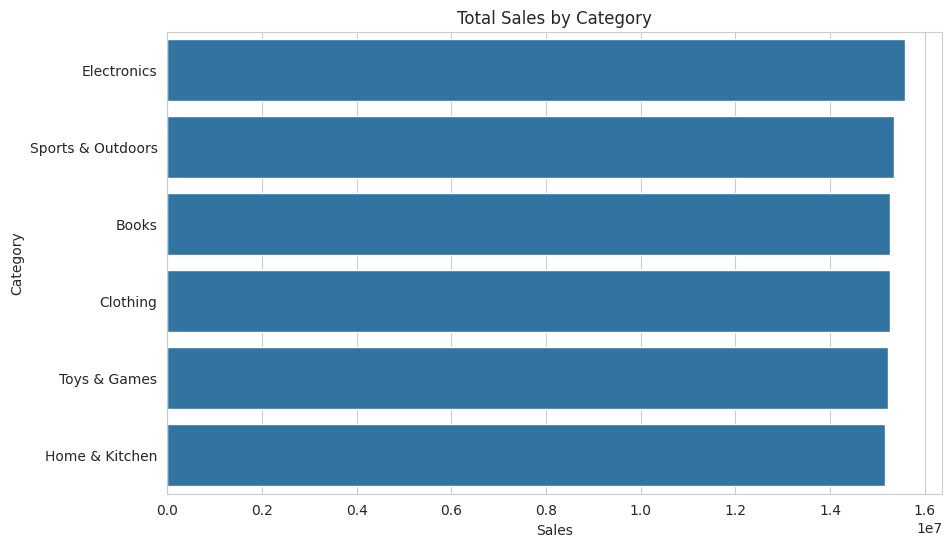

In [19]:
category_sales = df.groupby('Category')['FinalSales'].sum().sort_values(ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x=category_sales.values, y=category_sales.index)
plt.title("Total Sales by Category")
plt.xlabel("Sales")
plt.ylabel("Category")
plt.show()

Chart-2 — Top 10 Selling Products

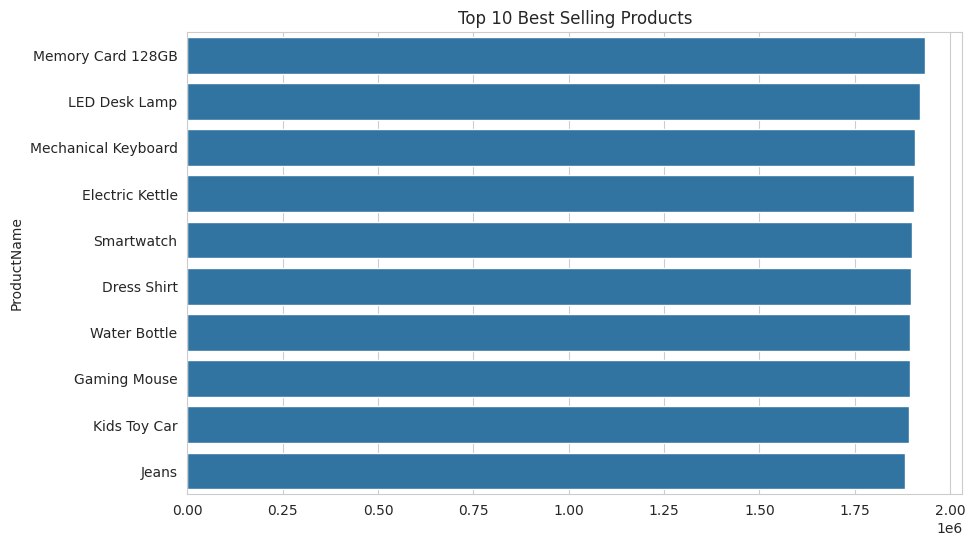

In [20]:
top_products = df.groupby('ProductName')['FinalSales'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))
sns.barplot(x=top_products.values, y=top_products.index)
plt.title("Top 10 Best Selling Products")
plt.show()

Chart-3 — Monthly Sales Trend

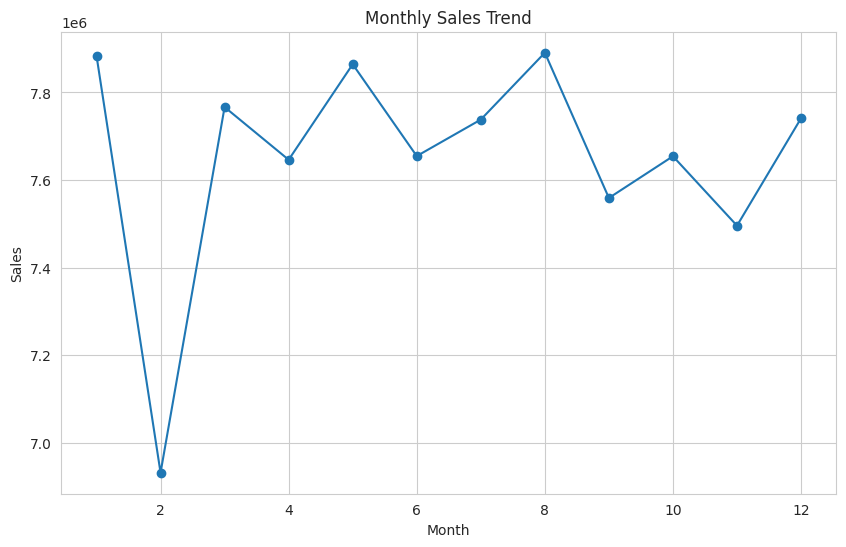

In [21]:
monthly_sales = df.groupby('Month')['FinalSales'].sum()

plt.figure(figsize=(10,6))
monthly_sales.plot(kind='line', marker='o')
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.show()

Chart-4 — Sales by Country

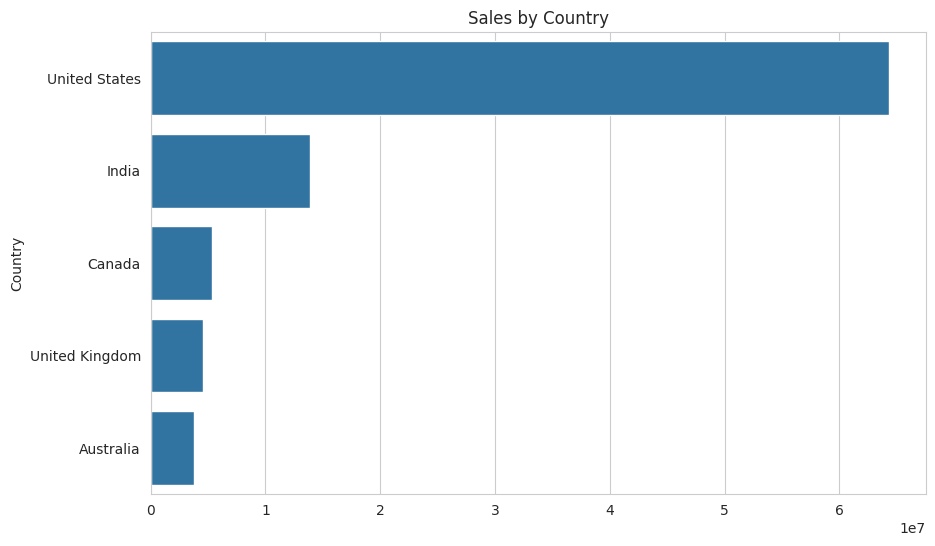

In [22]:
country_sales = df.groupby('Country')['FinalSales'].sum().sort_values(ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x=country_sales.values, y=country_sales.index)
plt.title("Sales by Country")
plt.show()

Chart-5 — Payment Method Distribution

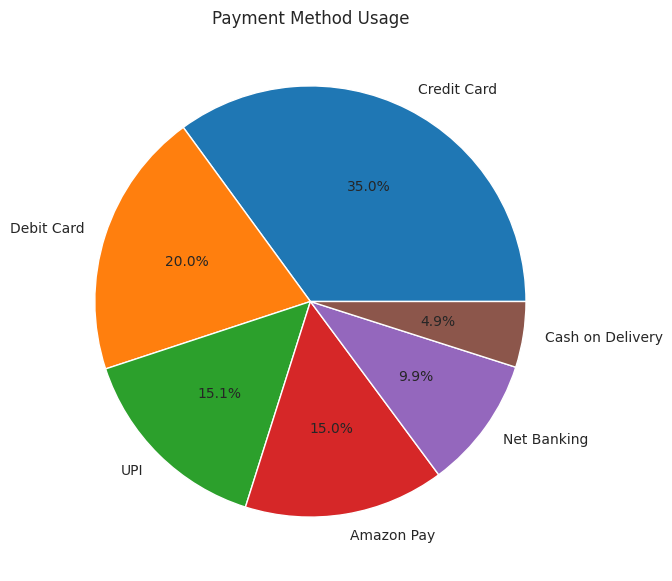

In [23]:
payment_counts = df['PaymentMethod'].value_counts()

plt.figure(figsize=(7,7))
plt.pie(payment_counts, labels=payment_counts.index, autopct='%1.1f%%')
plt.title("Payment Method Usage")
plt.show()

Chart-6 — Order Status Distribution

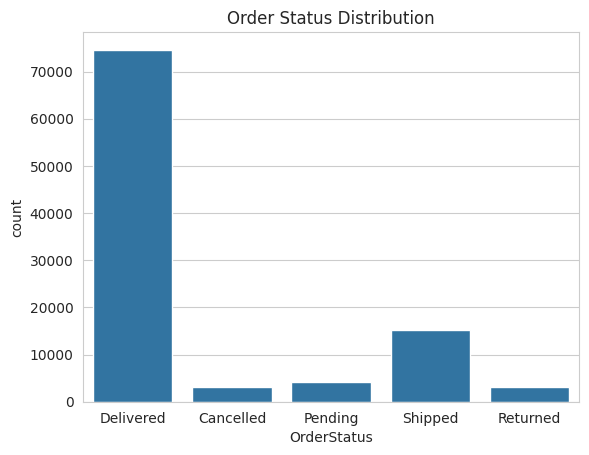

In [24]:
sns.countplot(data=df, x='OrderStatus')

plt.title("Order Status Distribution")
plt.show()

Chart-7 — Discount vs Sales

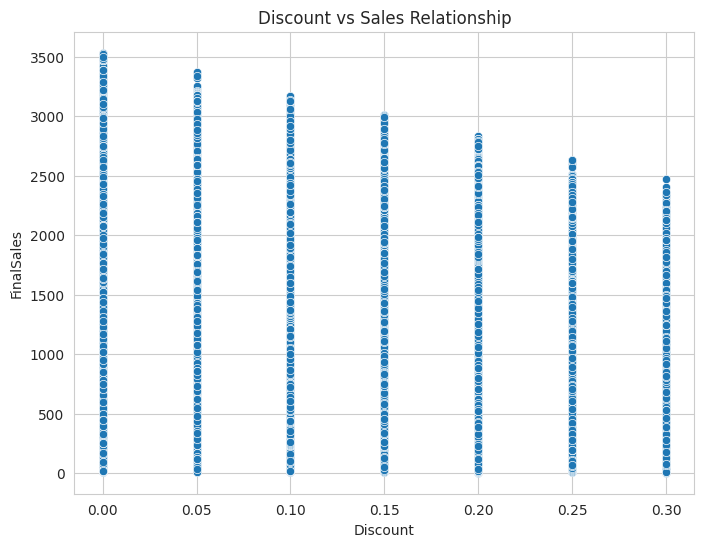

In [25]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x='Discount', y='FinalSales')
plt.title("Discount vs Sales Relationship")
plt.show()

chart-8 Top Cities by Sales

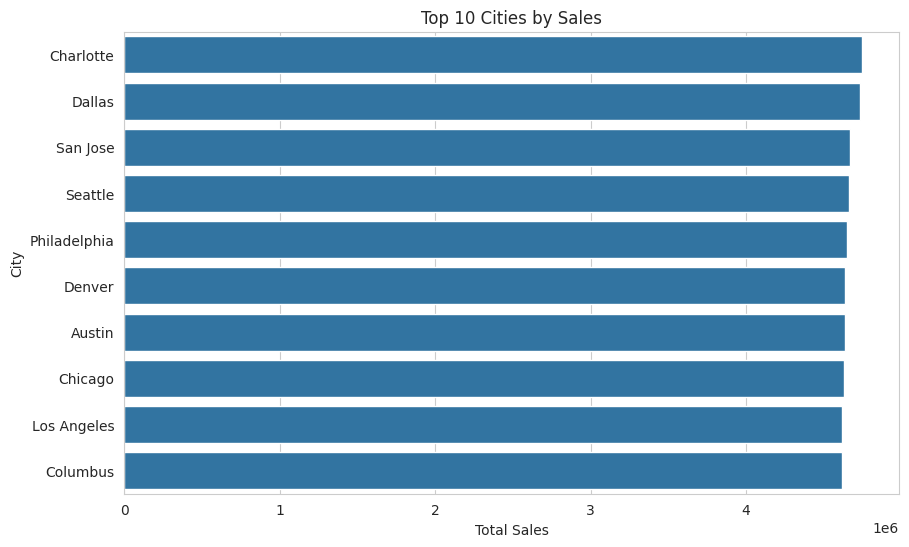

In [26]:
city_sales = df.groupby('City')['FinalSales'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))
sns.barplot(x=city_sales.values, y=city_sales.index)

plt.title("Top 10 Cities by Sales")
plt.xlabel("Total Sales")
plt.ylabel("City")

plt.show()

chart-9 Revenue Trend by Year

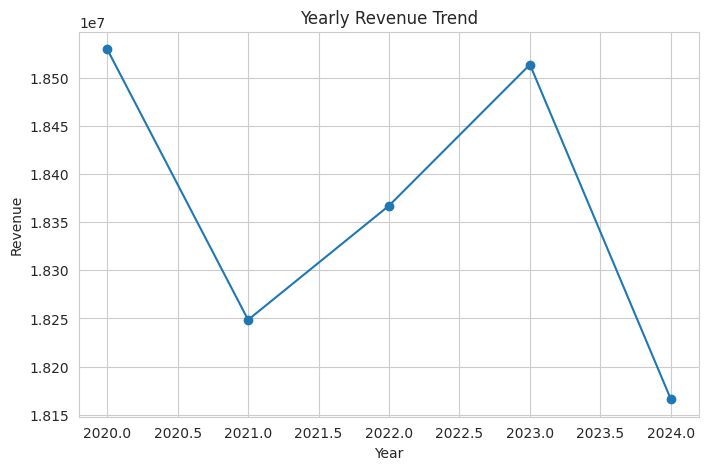

In [27]:
yearly_sales = df.groupby('Year')['FinalSales'].sum()

plt.figure(figsize=(8,5))
yearly_sales.plot(kind='line', marker='o')

plt.title("Yearly Revenue Trend")
plt.xlabel("Year")
plt.ylabel("Revenue")

plt.show()

chart-10 Category vs Discount Impact

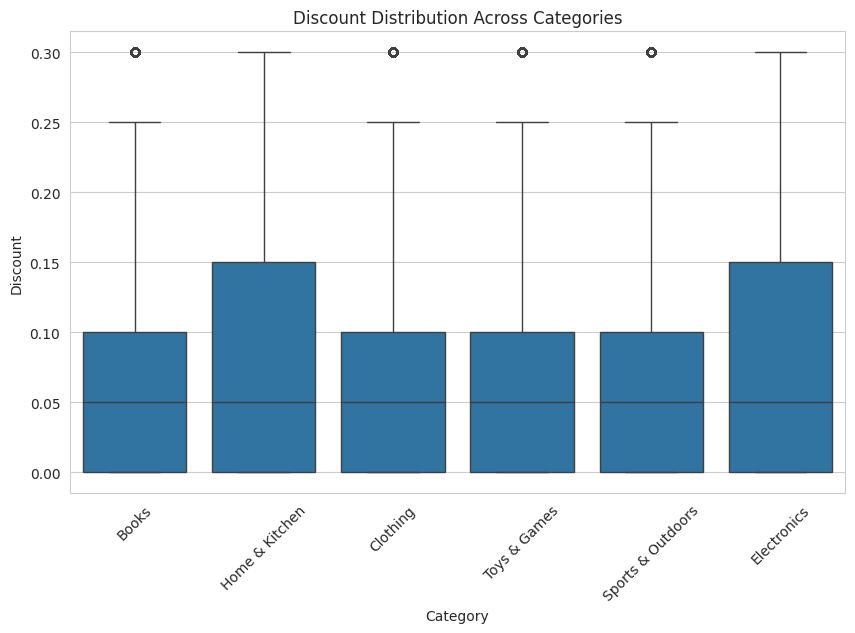

In [28]:
plt.figure(figsize=(10,6))

sns.boxplot(data=df, x='Category', y='Discount')

plt.title("Discount Distribution Across Categories")
plt.xticks(rotation=45)

plt.show()

#**Advanced Analysis**

Top 10 Customers by Spending

In [29]:
top_customers = df.groupby('CustomerName')['FinalSales'].sum().sort_values(ascending=False).head(10)

top_customers

,FinalSales
CustomerName,
Pooja Kapoor,547832.7385
Vihaan Singh,526675.8435
Pooja Singh,516451.6225
Kabir Joshi,515361.6970
Aditya Gupta,515005.0980
Mohit Singh,513513.1015
Sunita Mehta,511642.8695
Aman Reddy,511236.9105
Karan Singh,510900.6590


Best Selling Brand

In [30]:
brand_sales = df.groupby('Brand')['FinalSales'].sum().sort_values(ascending=False).head(10)

brand_sales

,FinalSales
Brand,
CoreTech,9.343721e+06
KiddoFun,9.324750e+06
ReadMore,9.278407e+06
UrbanStyle,9.249028e+06
Zenith,9.239961e+06
Apex,9.147605e+06
NexPro,9.078825e+06
FitLife,9.061445e+06
BrightLux,9.056816e+06


#**Final Business Insights**

Key Insights
The top product categories contribute the majority of total revenue.
A small number of products drive a large percentage of sales, showing a Pareto distribution.
Certain months show higher sales, indicating seasonal buying behavior.
Some countries generate significantly higher sales, showing strong regional markets.
Discounts moderately increase sales value, but excessive discounts reduce profit margins.
A small group of high-value customers contribute significantly to revenue.

#**Conclusion**

This project analyzed Amazon e-commerce sales data to uncover patterns in
customer purchasing behavior, product performance, and geographical sales
distribution.

Through data cleaning, feature engineering, and visualization, key business
insights were generated that can help companies optimize pricing strategies,
improve product marketing, and focus on high-performing markets.